In [ ]:
import numpy as np

def generar_datos(n, d, tol=1e-8):
    """
    Genera n puntos aleatorios en R^d y evita degeneraciones simples.
    Validación: varianza mínima positiva en el conjunto.
    """
    while True:
        P = np.random.randn(d, n)

        # Validación sencilla contra degeneración:
        # 1) Varianza total no nula
        if np.var(P) < tol:
            continue

        # 2) Ninguna dimensión colapsada
        if np.any(np.var(P, axis=1) < tol):
            continue

        return P


In [ ]:
from cvxopt import matrix, solvers
solvers.options['show_progress'] = False # Silenciar salida

def resolver_cvxopt(C):
    d, n = C.shape

    # Construcción de matrices para CVXOPT
    # Objetivo: min (1/2)x^T(2*C^TC)x + (-p_i^T p_i)x

    # 1. Matriz Q = 2 * (C^T * C)
    Q_np = 2 * np.dot(C.T, C)
    Q = matrix(Q_np)

    # 2. Vector lineal q = - (normas cuadradas de cada punto)
    # p_i^T p_i son los elementos de la diagonal de C^T C
    q_np = -np.diagonal(np.dot(C.T, C))
    q = matrix(q_np)

    # 3. Restricciones de Igualdad: sum(x) = 1  =>  A x = b
    A = matrix(1.0, (1, n))
    b = matrix(1.0)

    # 4. Restricciones de Desigualdad: x >= 0  =>  -x <= 0  => G x <= h
    G = matrix(-np.eye(n))
    h = matrix(0.0, (n, 1))

    # Resolver
    start_time = time.time()
    sol = solvers.qp(Q, q, G, h, A, b)
    end_time = time.time()

    x_opt = np.array(sol['x']).flatten()

    # Métricas
    tiempo = end_time - start_time
    iteraciones = sol['iterations'] # CVXOPT suele reportar esto

    return x_opt, tiempo, iteraciones

In [ ]:
from scipy.optimize import minimize

def resolver_scipy(C):
    d, n = C.shape

    # Pre-cálculo de matrices para eficiencia
    Q_mat = np.dot(C.T, C)
    diag_vals = np.diagonal(Q_mat)

    # Función Objetivo: x^T C^T C x - sum(p_i^T p_i * x_i)
    def objective(x):
        return x.dot(Q_mat).dot(x) - diag_vals.dot(x)

    # Jacobiano (Gradiente) para acelerar SciPy: 2*Q*x - diag
    def jacobian(x):
        return 2 * Q_mat.dot(x) - diag_vals

    # Restricciones
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = [(0, None) for _ in range(n)]

    # Guess inicial (distribución uniforme)
    x0 = np.ones(n) / n

    start_time = time.time()
    res = minimize(objective, x0, method='SLSQP', jac=jacobian,
                   bounds=bounds, constraints=constraints)
    end_time = time.time()

    return res.x, end_time - start_time, res.nit

Iniciando experimento: 29 dimensiones, 20 instancias c/u...
Procesando dimensión d=5...
Procesando dimensión d=10...
Procesando dimensión d=15...
Procesando dimensión d=20...
Procesando dimensión d=25...
Procesando dimensión d=30...


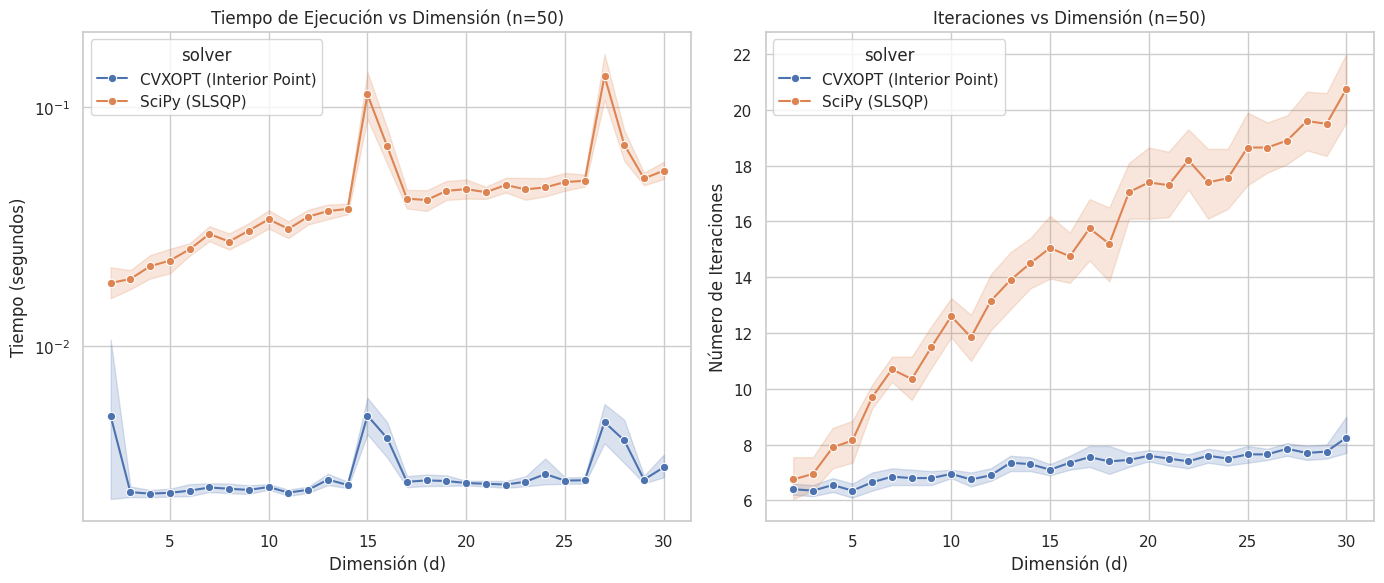


Resumen parcial (primeras 5 dimensiones):
                                     tiempo  iteraciones
dimension solver                                        
2         CVXOPT (Interior Point)  0.005090         6.40
          SciPy (SLSQP)            0.018358         6.75
3         CVXOPT (Interior Point)  0.002445         6.35
          SciPy (SLSQP)            0.019074         6.95
4         CVXOPT (Interior Point)  0.002410         6.55
          SciPy (SLSQP)            0.021581         7.90
5         CVXOPT (Interior Point)  0.002429         6.35
          SciPy (SLSQP)            0.022772         8.15
6         CVXOPT (Interior Point)  0.002480         6.65
          SciPy (SLSQP)            0.025411         9.70


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cvxopt import matrix, solvers
from scipy.optimize import minimize
import time

# --- (Asegúrate de incluir aquí las funciones definidas previamente:
#      generar_datos, resolver_cvxopt, resolver_scipy) ---

# Configuración del experimento
dims = range(2, 31)  # d = 2...30
n_instancias = 20    # 20 instancias por dimensión
n_puntos = 50        # n = 50 fijo

# Almacenamiento de resultados
resultados = {
    'dimension': [],
    'solver': [],
    'tiempo': [],
    'iteraciones': []
}

print(f"Iniciando experimento: {len(dims)} dimensiones, {n_instancias} instancias c/u...")

for d in dims:
    # Feedback visual para el usuario
    if d % 5 == 0:
        print(f"Procesando dimensión d={d}...")

    for i in range(n_instancias):
        # 1. Generar instancia aleatoria válida
        C = generar_datos(n_puntos, d)

        # 2. Solver CVXOPT (Interior Point)
        try:
            _, t_cvx, it_cvx = resolver_cvxopt(C)
            resultados['dimension'].append(d)
            resultados['solver'].append('CVXOPT (Interior Point)')
            resultados['tiempo'].append(t_cvx)
            resultados['iteraciones'].append(it_cvx)
        except Exception as e:
            print(f"Error en CVXOPT d={d} inst={i}: {e}")

        # 3. Solver Scipy (SQP / Active Set)
        try:
            _, t_sci, it_sci = resolver_scipy(C)
            resultados['dimension'].append(d)
            resultados['solver'].append('SciPy (SLSQP)')
            resultados['tiempo'].append(t_sci)
            resultados['iteraciones'].append(it_sci)
        except Exception as e:
            print(f"Error en SciPy d={d} inst={i}: {e}")

# Convertir a DataFrame para facilitar análisis
df = pd.DataFrame(resultados)

# --- VISUALIZACIÓN DE RESULTADOS ---

# Configuración de estilo
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1: Tiempo Promedio de Ejecución
sns.lineplot(ax=axes[0], data=df, x='dimension', y='tiempo', hue='solver', marker="o")
axes[0].set_title('Tiempo de Ejecución vs Dimensión (n=50)')
axes[0].set_ylabel('Tiempo (segundos)')
axes[0].set_xlabel('Dimensión (d)')
axes[0].set_yscale('log') # Escala logarítmica recomendada por diferencias de magnitud

# Gráfica 2: Número Promedio de Iteraciones
sns.lineplot(ax=axes[1], data=df, x='dimension', y='iteraciones', hue='solver', marker="o")
axes[1].set_title('Iteraciones vs Dimensión (n=50)')
axes[1].set_ylabel('Número de Iteraciones')
axes[1].set_xlabel('Dimensión (d)')

plt.tight_layout()
plt.show()

# --- TABLA RESUMEN (Para el reporte) ---
resumen = df.groupby(['dimension', 'solver']).mean()
print("\nResumen parcial (primeras 5 dimensiones):")
print(resumen.head(10))

In [ ]:
# ... (Todo el código anterior de generación y gráficas se mantiene igual) ...

# --- TABLA RESUMEN ESPECÍFICA (Para el inciso d) ---

# 1. Agrupamos por dimensión y solver calculando el promedio
resumen = df.groupby(['dimension', 'solver'])[['tiempo', 'iteraciones']].mean()

# 2. Definimos las dimensiones de interés para el reporte
dims_interes = [2, 5, 10, 15, 20, 25, 30]

# 3. Filtramos usando .loc (buscando en el índice 'dimension')
#    Nota: El índice es MultiIndex (dimension, solver), así que seleccionamos por el nivel 0
tabla_reporte = resumen.query(f"dimension in {dims_interes}")

print("\n" + "="*60)
print(f"TABLA COMPARATIVA: Dimensiones {dims_interes}")
print("="*60)
pd.set_option('display.float_format', '{:.6f}'.format) # Formato limpio
print(tabla_reporte)
print("="*60)

# Opcional: Guardar a CSV o LaTeX para copiar al reporte
# tabla_reporte.to_csv('resumen_proyecto.csv')
# print(tabla_reporte.to_latex())


TABLA COMPARATIVA: Dimensiones [2, 5, 10, 15, 20, 25, 30]
                                    tiempo  iteraciones
dimension solver                                       
2         CVXOPT (Interior Point) 0.005090     6.400000
          SciPy (SLSQP)           0.018358     6.750000
5         CVXOPT (Interior Point) 0.002429     6.350000
          SciPy (SLSQP)           0.022772     8.150000
10        CVXOPT (Interior Point) 0.002570     6.950000
          SciPy (SLSQP)           0.033902    12.600000
15        CVXOPT (Interior Point) 0.005110     7.100000
          SciPy (SLSQP)           0.112951    15.050000
20        CVXOPT (Interior Point) 0.002670     7.600000
          SciPy (SLSQP)           0.045357    17.400000
25        CVXOPT (Interior Point) 0.002733     7.650000
          SciPy (SLSQP)           0.048554    18.650000
30        CVXOPT (Interior Point) 0.003107     8.250000
          SciPy (SLSQP)           0.054182    20.750000


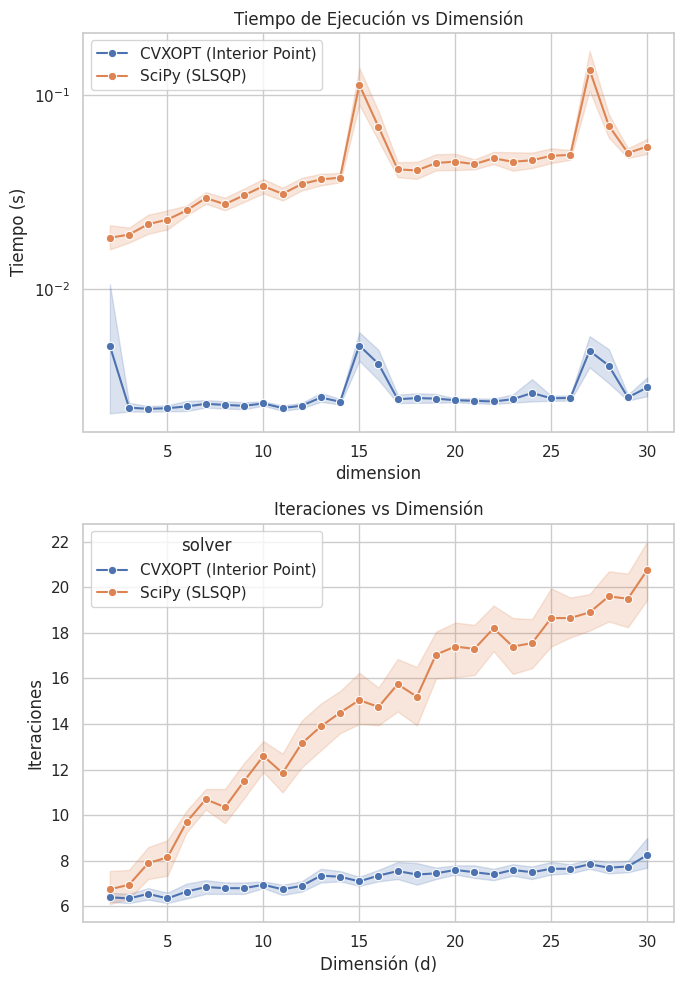

In [ ]:
# --- VISUALIZACIÓN VERTICAL (Estilo Columna) ---
sns.set(style="whitegrid")

# figsize=(ancho, alto): (7, 10) crea una imagen alta
fig, axes = plt.subplots(2, 1, figsize=(7, 10))

# Gráfica 1: Tiempo (Arriba)
sns.lineplot(ax=axes[0], data=df, x='dimension', y='tiempo', hue='solver', marker="o")
axes[0].set_title('Tiempo de Ejecución vs Dimensión')
axes[0].set_ylabel('Tiempo (s)')
axes[0].set_yscale('log')
axes[0].legend(loc='upper left')

# Gráfica 2: Iteraciones (Abajo)
sns.lineplot(ax=axes[1], data=df, x='dimension', y='iteraciones', hue='solver', marker="o")
axes[1].set_title('Iteraciones vs Dimensión')
axes[1].set_ylabel('Iteraciones')
axes[1].set_xlabel('Dimensión (d)')

plt.tight_layout()
# Guardar con alta resolución para que se vea nítida al reducirla
plt.savefig('grafica_columna.png', dpi=300, bbox_inches='tight')
plt.show()